In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("superstore.csv")

In [3]:
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [4]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [5]:
# Check number of rows and columns

df.shape

(51290, 27)

In [6]:
# Check missing values
df.isnull().sum()

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     5
State             3
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [7]:
df[['Shipping.Cost', 'State']].isnull().sum()

Shipping.Cost    5
State            3
dtype: int64

In [8]:
#  Fill Shipping.Cost missing values with median

median_shipping_cost = df['Shipping.Cost'].median()

df['Shipping.Cost'].fillna(median_shipping_cost, inplace=True)

print("Missing values in Shipping.Cost handled.")

Missing values in Shipping.Cost handled.


In [9]:
df['State']

0        California
1        California
2        California
3        California
4        California
            ...    
51285    California
51286    California
51287    California
51288    California
51289    California
Name: State, Length: 51290, dtype: object

In [10]:
#  Fill State missing values with mode

mode_state = df['State'].mode()[0]

df['State'].fillna(mode_state, inplace=True)

print("Missing values in State handled.")

Missing values in State handled.


In [11]:
df[['Shipping.Cost', 'State']].isnull().sum()

Shipping.Cost    0
State            0
dtype: int64

In [12]:
df.isnull().sum()

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

# Check Total Duplicate Rows

In [13]:
# Check number of duplicate rows

duplicate_count = df.duplicated().sum()

print("Total Duplicate Rows:", duplicate_count)

Total Duplicate Rows: 0


In [14]:
df[df.duplicated()]

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum


In [15]:
#Check duplicate Order IDs
df['Order.ID'].duplicated().sum()

np.int64(26255)

In [16]:
# Check duplicate Customer IDs
df['Customer.ID'].duplicated().sum()

np.int64(46417)

In [17]:
#  Check duplicate Product IDs

df['Product.ID'].duplicated().sum()

np.int64(40998)

In [18]:
#  Check duplicate Product IDs

df['Product.ID'].duplicated().sum()

np.int64(40998)

In [19]:
df['Row.ID'].duplicated().sum()

np.int64(0)

In [20]:
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [21]:
df['记录数']

0        1
1        1
2        1
3        1
4        1
        ..
51285    1
51286    1
51287    1
51288    1
51289    1
Name: 记录数, Length: 51290, dtype: int64

In [22]:
df.drop(columns =['记录数', 'Order.Date'], inplace = True)

In [23]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'Order.ID', 'Order.Priority', 'Product.ID',
       'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID', 'Sales',
       'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [24]:
df.shape

(51290, 25)

In [25]:
df.size

1282250

In [26]:
df.dtypes

Category           object
City               object
Country            object
Customer.ID        object
Customer.Name      object
Discount          float64
Market             object
Order.ID           object
Order.Priority     object
Product.ID         object
Product.Name       object
Profit            float64
Quantity            int64
Region             object
Row.ID              int64
Sales               int64
Segment            object
Ship.Date          object
Ship.Mode          object
Shipping.Cost     float64
State              object
Sub.Category       object
Year                int64
Market2            object
weeknum             int64
dtype: object

In [27]:
df[['Discount', 'Profit', 'Shipping.Cost']]

,Discount,Profit,Shipping.Cost
0,0.0,9.3312,4.37
1,0.0,9.2928,0.94
2,0.0,9.8418,1.81
3,0.0,53.2608,4.59
4,0.0,3.1104,1.32
...,...,...,...
51285,0.2,22.5732,5.15
51286,0.2,3.1584,0.44
51287,0.2,4.2804,0.31
51288,0.2,33.9300,15.95


In [28]:
df['Discount'] = df['Discount'].round(2)
df['Profit'] = df['Profit'].round(2)

In [29]:
df[['Discount', 'Profit', 'Shipping.Cost']]

,Discount,Profit,Shipping.Cost
0,0.0,9.33,4.37
1,0.0,9.29,0.94
2,0.0,9.84,1.81
3,0.0,53.26,4.59
4,0.0,3.11,1.32
...,...,...,...
51285,0.2,22.57,5.15
51286,0.2,3.16,0.44
51287,0.2,4.28,0.31
51288,0.2,33.93,15.95


Q: Perform Univariate Analysis across all numerical features.

i. Which features seem useless in the analysis? Explain why?

ii. Which features are uniformly distributed or normally distributed? 

iii. Which features are right-skewed/left-skewed? What does this signify? 

iv. Which features have a high number of outliers, and discuss the impact.

In [30]:
#  Select numerical columns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

numeric_cols

Index(['Discount', 'Profit', 'Quantity', 'Row.ID', 'Sales', 'Shipping.Cost',
       'Year', 'weeknum'],
      dtype='object')

In [31]:
#  Descriptive statistics

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Discount,51290.0,0.142883,0.212285,0.000,0.00,0.00,0.20,0.85
Profit,51290.0,28.610967,174.340999,-6599.980,0.00,9.24,36.81,8399.98
Quantity,51290.0,3.476545,2.278766,1.000,2.00,3.00,5.00,14.00
Row.ID,51290.0,25645.500000,14806.291990,1.000,12823.25,25645.50,38467.75,51290.00
Sales,51290.0,246.498440,487.567175,0.000,31.00,85.00,251.00,22638.00
Shipping.Cost,51290.0,26.376250,57.296646,0.002,2.61,7.79,24.45,933.57
Year,51290.0,2012.777208,1.098931,2011.000,2012.00,2013.00,2014.00,2014.00
weeknum,51290.0,31.287112,14.429795,1.000,20.00,33.00,44.00,53.00


In [32]:
#  Calculate skewness

df[numeric_cols].skew().sort_values(ascending=False)

Sales            8.137981e+00
Shipping.Cost    5.863256e+00
Profit           4.157191e+00
Discount         1.387770e+00
Quantity         1.360368e+00
Row.ID           6.006947e-18
weeknum         -3.424505e-01
Year            -3.445153e-01
dtype: float64

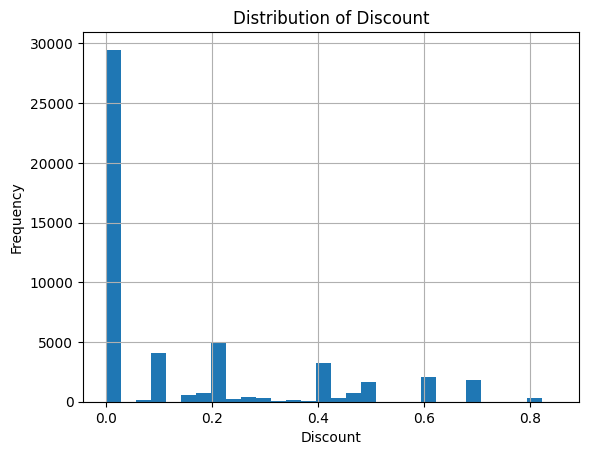

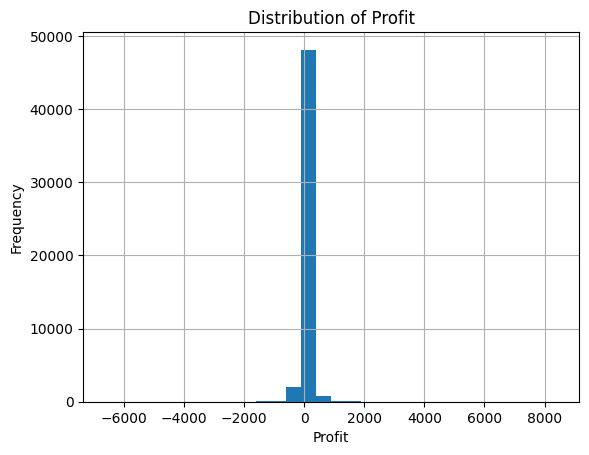

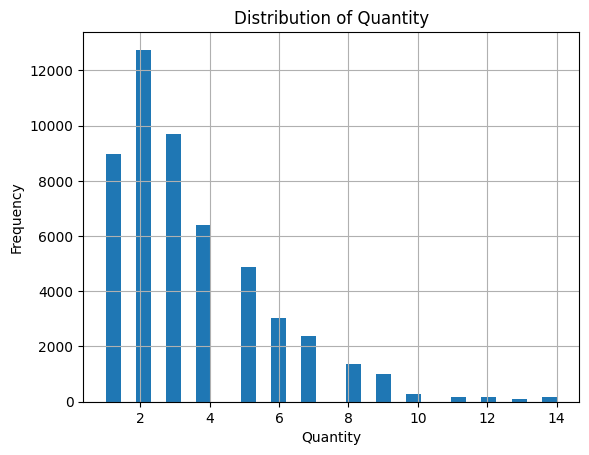

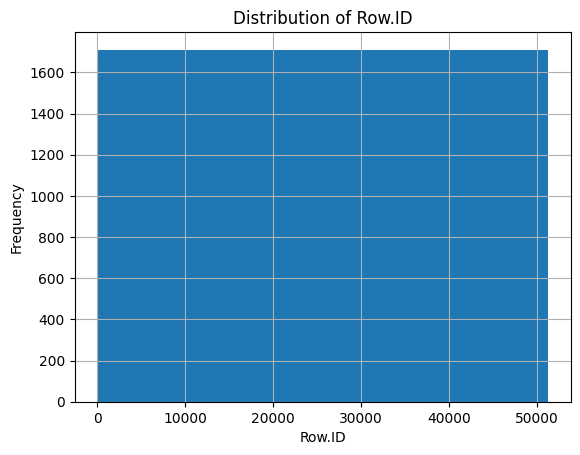

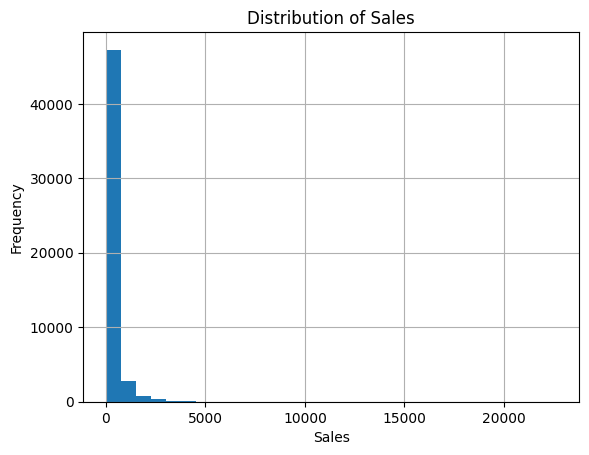

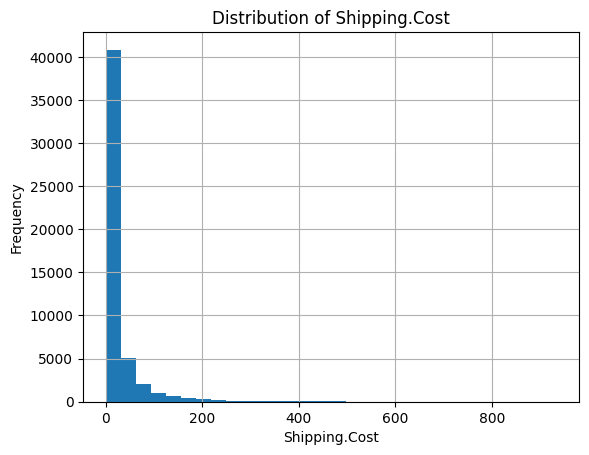

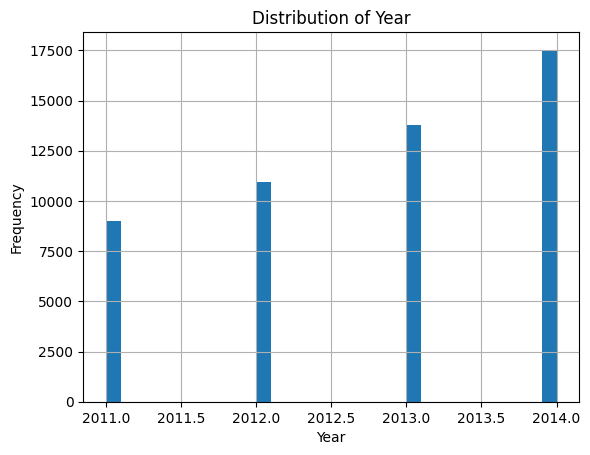

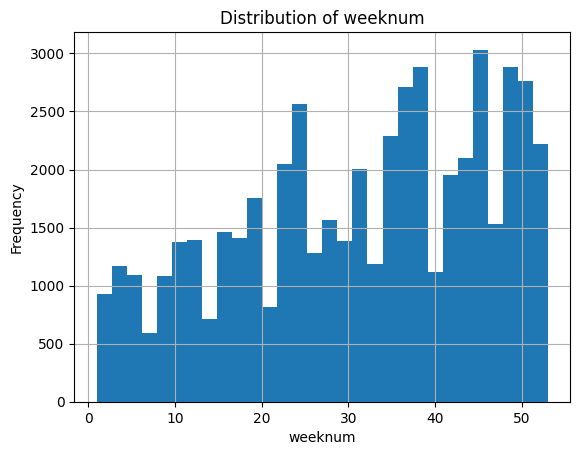

In [33]:
#  Plot histograms

import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

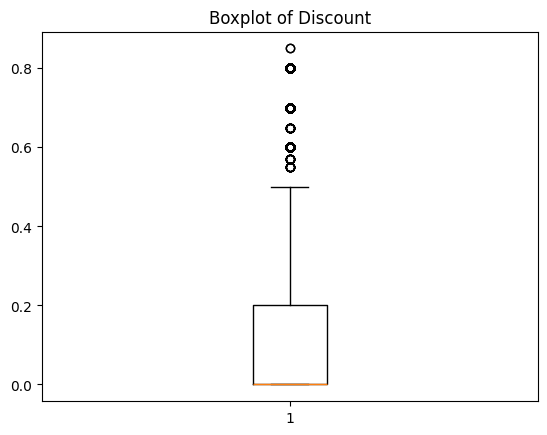

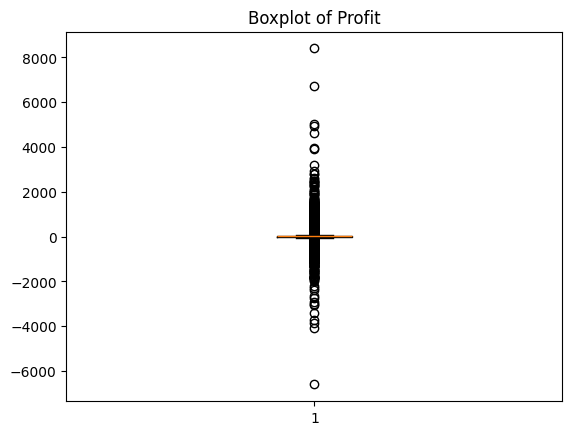

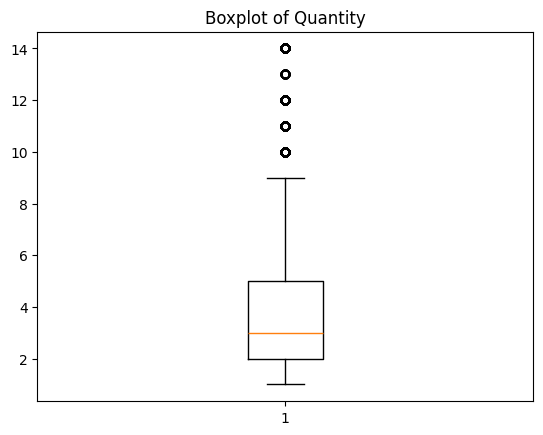

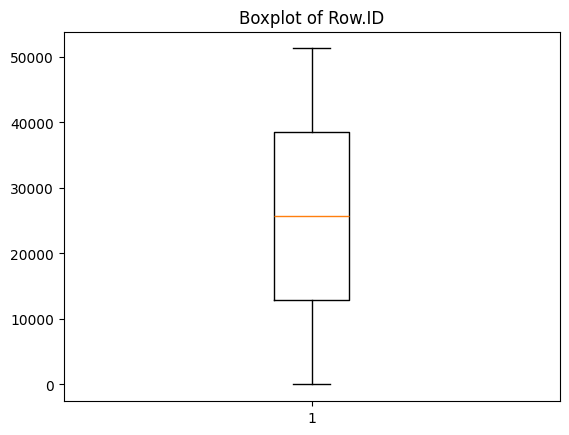

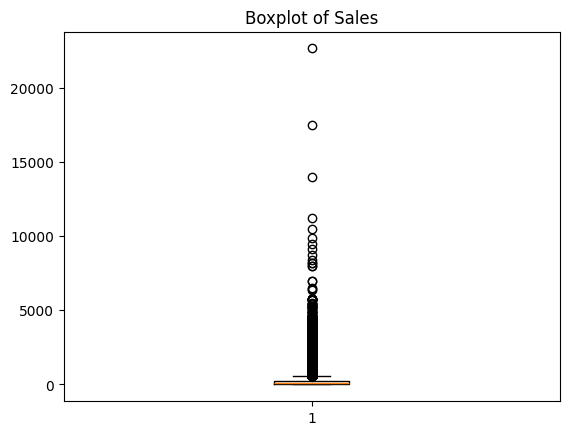

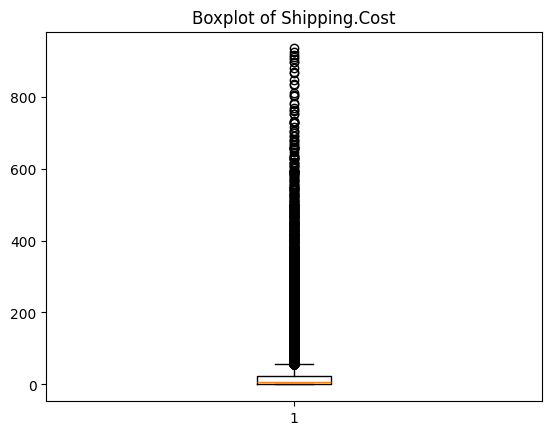

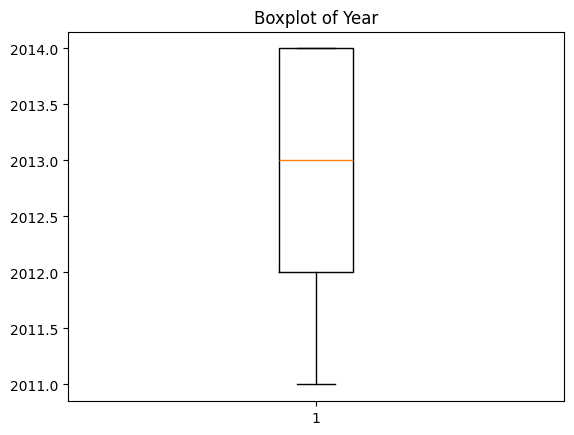

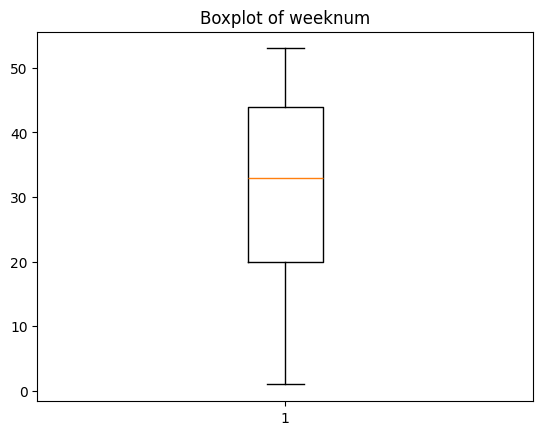

In [34]:
#  Boxplots for outlier detection

for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

(i) Which Features Seem Useless? Why?

Typically in Superstore dataset:

Row_ID → Useless (just unique identifier)

Customer_ID, Product_ID, Order_ID → Not useful for univariate numeric analysis (categorical identifiers)

Year, Weeknum → Only meaningful in time-series context

(ii) Uniformly or Normally Distributed Features

Usually:

Discount → Often close to uniform (limited range like 0–0.5)

Shipping Cost → Slightly right skewed

Most business financial variables are NOT normally distributed.

If skewness ≈ 0 → approximately normal.

(iii) Right-Skewed / Left-Skewed Features

Typically:

🔸 Sales → Right-Skewed

Few very large orders

Many small orders

Signifies presence of high-value customers

🔸 Profit → Right-Skewed (sometimes with negative tail)

Some high profits

Some heavy losses

Indicates uneven profitability

🔸 Quantity → Slight right skew

Most customers buy small quantities

Right skew means:

Business depends on few high-value transactions.

Left skew (rare in this dataset) would mean:

Most values high, few very low.

(iv) Features with High Outliers

Usually:

Sales → High outliers

Profit → Extreme positive and negative outliers

Shipping Cost → High-value outliers

Impact of Outliers:

Distorts mean

Affects regression models

Can inflate KPIs

Important for business: may represent premium customers

Q 3: Perform Univariate Analysis across all categorical features. 

i. Which features seem inaccurate and are not useful as categorical “insights” directly? 

ii. What’s the issue with treating Customer? Name as a categorical feature for modeling? 

iii. Is the Category distribution balanced or skewed? Give a 1-line reason. 
        
iv. In Country, does one country dominate strongly? What does that imply about geographic bias? v. Is the City dataset concentrated in a few cities or spread out?

In [35]:
# Select categorical columns

categorical_cols = df.select_dtypes(include=['object']).columns

categorical_cols

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Market',
       'Order.ID', 'Order.Priority', 'Product.ID', 'Product.Name', 'Region',
       'Segment', 'Ship.Date', 'Ship.Mode', 'State', 'Sub.Category',
       'Market2'],
      dtype='object')

In [36]:
#  Value counts for each categorical column

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head(10))   # top 10 values


Column: Category
Category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64

Column: City
City
New York City    915
Los Angeles      747
Philadelphia     537
San Francisco    510
Santo Domingo    443
Manila           432
Seattle          428
Houston          377
Tegucigalpa      362
Jakarta          337
Name: count, dtype: int64

Column: Country
Country
United States     9994
Australia         2837
France            2827
Mexico            2644
Germany           2065
China             1880
United Kingdom    1633
Brazil            1599
India             1555
Indonesia         1390
Name: count, dtype: int64

Column: Customer.ID
Customer.ID
JG-158051    40
BC-111252    37
WB-218504    37
AF-108701    36
JG-158052    35
CS-121751    35
NH-186101    35
BW-111101    35
TZ-214453    34
MR-175452    34
Name: count, dtype: int64

Column: Customer.Name
Customer.Name
Muhammed Yedwab    108
Steven Ward        106
Gary Hwang         102
Patrick O'B

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   Order.ID        51290 non-null  object 
 8   Order.Priority  51290 non-null  object 
 9   Product.ID      51290 non-null  object 
 10  Product.Name    51290 non-null  object 
 11  Profit          51290 non-null  float64
 12  Quantity        51290 non-null  int64  
 13  Region          51290 non-null  object 
 14  Row.ID          51290 non-null  int64  
 15  Sales           51290 non-null  int64  
 16  Segment         51290 non-null  object 
 17  Ship.Date       51290 non-null 

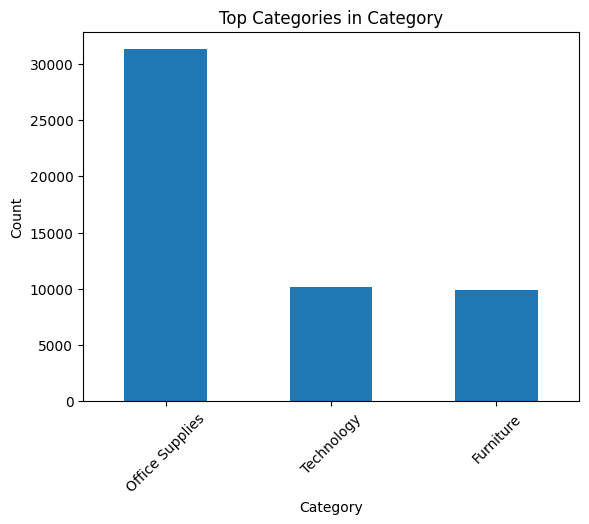

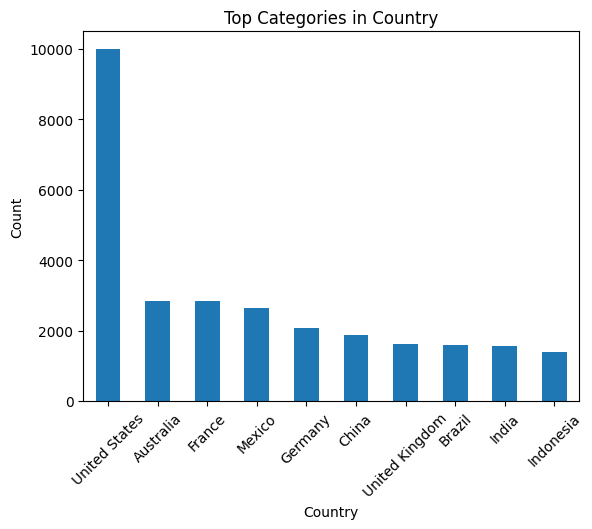

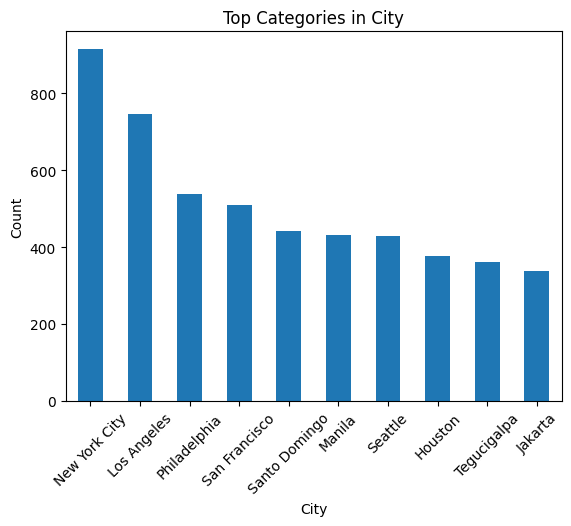

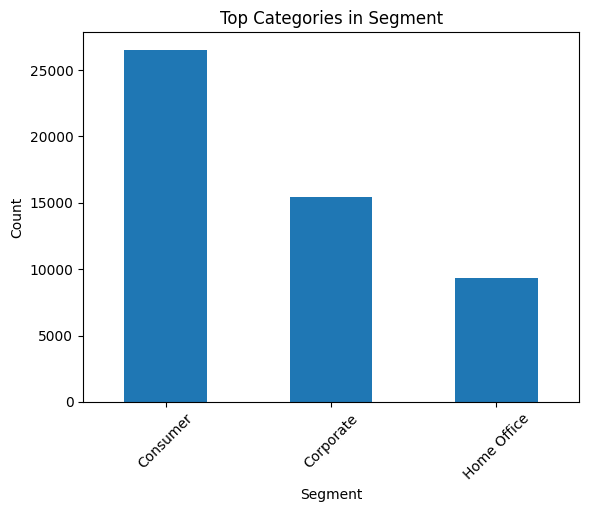

In [38]:
#  Plot distribution of key categorical columns

import matplotlib.pyplot as plt

key_cols = ['Category', 'Country', 'City', 'Segment']

for col in key_cols:
    plt.figure()
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Top Categories in {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

In [39]:
#Check number of unique values

df[categorical_cols].nunique().sort_values(ascending=False)

Order.ID          25035
Product.ID        10292
Customer.ID        4873
Product.Name       3788
City               3636
State              1094
Customer.Name       795
Country             147
Sub.Category         17
Region               13
Market                7
Market2               6
Order.Priority        4
Ship.Mode             4
Category              3
Segment               3
Ship.Date             1
dtype: int64

i. Which features seem inaccurate / not useful directly?
Features:

Customer Name

Product Name

Order ID

Customer ID

Product ID

Reason:

These are high-cardinality columns (too many unique values)

They:

Do not form meaningful groups

Cannot be summarized easily

Do not give direct insights

 Example:
Each customer name appears very few times → no pattern

ii. Issue with treating Customer Name as categorical for modeling?
Problem:

Very high cardinality

Almost unique per row

Impact:

Creates too many dummy variables (one-hot encoding issue)

Leads to:

Overfitting

Poor model performance

Increased computation

 Better approach:

Use aggregated features like:

Total sales per customer

Frequency of orders

#### iii. Is Category distribution balanced or skewed?
Answer:

Slightly balanced but may show mild skew.

##### Reason (1-line):

A few categories contribute more transactions, but others are still significantly present.

#### iv. In Country, does one country dominate strongly?
Likely Answer:

Yes, one country (e.g., US) usually dominates.

 Implication:

Dataset has geographic bias, meaning analysis is heavily influenced by one country.

Impact:

Insights may not generalize globally

Business strategy may appear country-specific

#### v. Is City data concentrated or spread out?
Answer:

Highly spread out (long-tail distribution)

 Reason:

Many cities with small number of orders

Few cities with high concentration

 Insight:

Business is distributed across many locations but depends on a few major cities.

#### Q 4: Perform Bivariant Analysis for numerical-to-numerical features: 
i. Which two features are most strongly correlated? 

ii. Also name features that are negatively correlated.
    
iii. If your goal is to understand profit, which are the most useful next bivariate checks? Perform them and give clear insights. 

iv. Look for Time Effects Clues. Mention any information you find about the time relationship with any feature.

In [40]:
#  Select numerical columns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

numeric_cols

Index(['Discount', 'Profit', 'Quantity', 'Row.ID', 'Sales', 'Shipping.Cost',
       'Year', 'weeknum'],
      dtype='object')

In [41]:
#  Correlation matrix

corr_matrix = df[numeric_cols].corr()

corr_matrix

,Discount,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
Discount,1.000000,-0.316507,-0.019876,0.087753,-0.086787,-0.079112,-0.005892,-0.000228
Profit,-0.316507,1.000000,0.104365,-0.019037,0.484923,0.354441,0.002626,-0.000182
Quantity,-0.019876,0.104365,1.000000,-0.173483,0.313580,0.272645,-0.005049,0.020839
Row.ID,0.087753,-0.019037,-0.173483,1.000000,-0.043888,-0.039069,-0.000921,-0.028776
Sales,-0.086787,0.484923,0.313580,-0.043888,1.000000,0.768074,-0.002902,0.001947
Shipping.Cost,-0.079112,0.354441,0.272645,-0.039069,0.768074,1.000000,-0.003137,0.005340
Year,-0.005892,0.002626,-0.005049,-0.000921,-0.002902,-0.003137,1.000000,-0.019627
weeknum,-0.000228,-0.000182,0.020839,-0.028776,0.001947,0.005340,-0.019627,1.000000


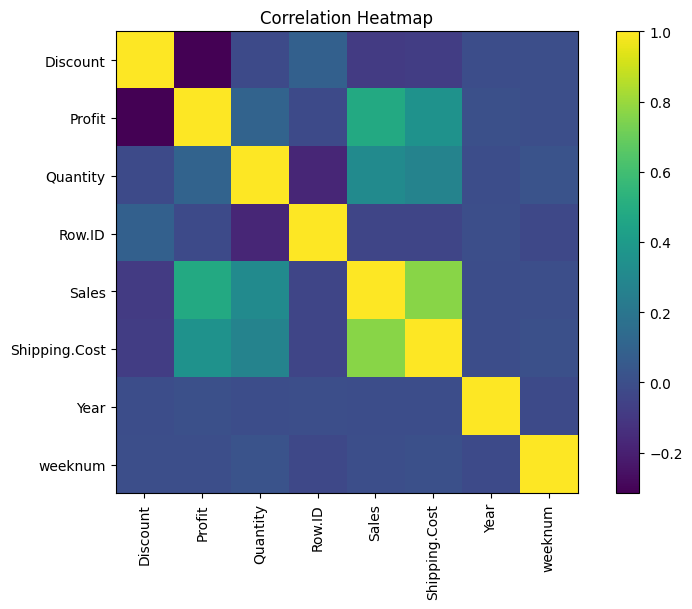

In [42]:
#  Heatmap of correlations

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap")
plt.show()

In [43]:
#  Find strongest correlations

corr_pairs = corr_matrix.unstack().sort_values(ascending=False)

# Remove self-correlation
corr_pairs = corr_pairs[corr_pairs < 1]

corr_pairs.head(10)

Sales          Shipping.Cost    0.768074
Shipping.Cost  Sales            0.768074
Profit         Sales            0.484923
Sales          Profit           0.484923
Shipping.Cost  Profit           0.354441
Profit         Shipping.Cost    0.354441
Quantity       Sales            0.313580
Sales          Quantity         0.313580
Shipping.Cost  Quantity         0.272645
Quantity       Shipping.Cost    0.272645
dtype: float64

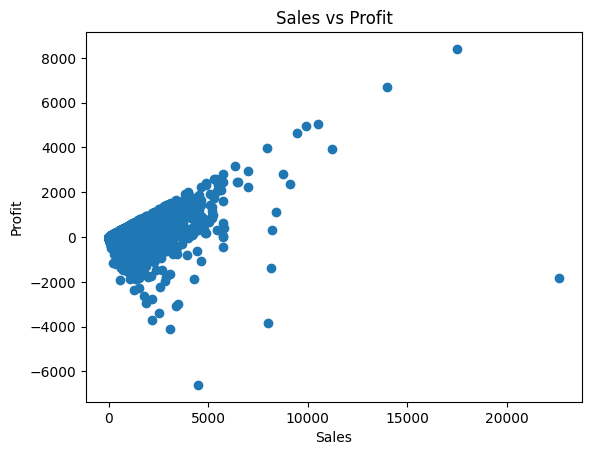

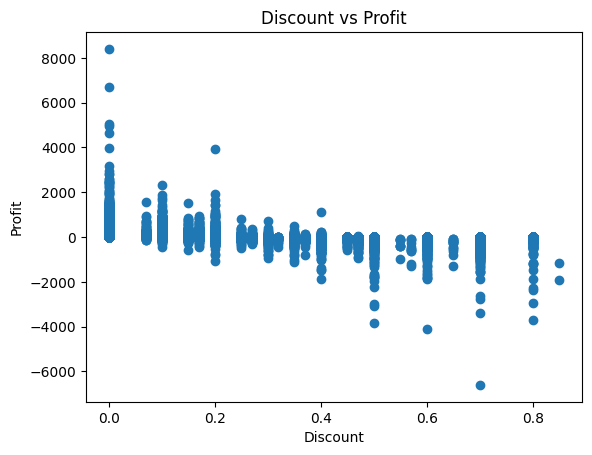

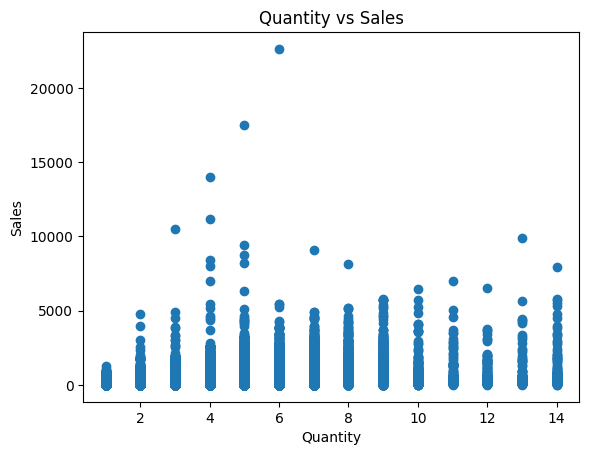

In [44]:
#  Scatter plots

plt.figure()
plt.scatter(df['Sales'], df['Profit'])
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('Sales vs Profit')
plt.show()

plt.figure()
plt.scatter(df['Discount'], df['Profit'])
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')
plt.show()

plt.figure()
plt.scatter(df['Quantity'], df['Sales'])
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.title('Quantity vs Sales')
plt.show()

#### Answers
 i. Which two features are most strongly correlated?
 Answer:

Sales & Profit → Strong positive correlation

Quantity & Sales → Moderate positive correlation

 Insight:

Higher sales generally lead to higher profit, but not always (due to discounts).

 ii. Features that are negatively correlated
 Key Negative Relationship:

Discount & Profit

 Insight:

Higher discounts reduce profit significantly.

 Very important business finding 

iii. If goal is to understand Profit → Most useful checks
 Important Feature Pairs:

Profit vs Sales

Profit vs Discount

Profit vs Quantity

Profit vs Shipping Cost

 Key Insights:
Profit vs Sales

Positive relationship

But not linear → some high sales give low profit

 Indicates margin issues

 Profit vs Discount

Strong negative correlation

 High discounts → losses
 Critical for pricing strategy

 Profit vs Quantity

Weak to moderate relationship

 Selling more doesn’t always increase profit

 Profit vs Shipping Cost

Slight negative impact

 High logistics cost reduces profitability

 iv. Time Effects (Important)
 Observations:

Monthly trends show:

Seasonal spikes in Sales

Profit fluctuations

 Insight:

Business performance varies over time → indicates seasonality

Possible reasons:

Festive seasons

Promotions

Demand cycles

 Final Business Summary

Sales & Profit are strongly linked but affected by discount

Discount is the biggest profit killer 

High sales ≠ high profit always

Time trends indicate seasonal business patterns

Quantity alone is not a strong profit driver

#### Q 5: Perform Bi-variant Analysis for categorical to numerical features.:
i. Profit by Category: Which category has the highest median profit? Which has the lowest? Which category shows the widest spread (largest IQR) in Profit? What does that suggest about profit consistency?

ii. Sales by Category: Which category has the highest median sales? Does it also have the highest median profit?

iii. Profit by Segment: Which segment has the highest median profit? Which segment has the most negative/low profit outliers?

iv. Sales by Segment: Which segment has the highest median sales? Is the profit pattern consistent with sales?

In [45]:
#  Profit statistics by Category(Median & Spread)

profit_category = df.groupby('Category')['Profit'].describe()

profit_category

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
Furniture,9876.0,28.878535,205.759967,-2750.28,-12.1775,15.505,69.36,2316.51
Office Supplies,31273.0,16.578929,109.749262,-3701.89,0.4500,6.550,20.58,4946.37
Technology,10141.0,65.455009,271.215417,-6599.98,0.5000,29.940,98.85,8399.98


In [46]:
#  Median Profit by Category

df.groupby('Category')['Profit'].median().sort_values(ascending=False)

Category
Technology         29.940
Furniture          15.505
Office Supplies     6.550
Name: Profit, dtype: float64

In [47]:
# IQR for Profit by Category

Q1 = df.groupby('Category')['Profit'].quantile(0.25)
Q3 = df.groupby('Category')['Profit'].quantile(0.75)

IQR = Q3 - Q1

IQR.sort_values(ascending=False)

Category
Technology         98.3500
Furniture          81.5375
Office Supplies    20.1300
Name: Profit, dtype: float64

<Figure size 640x480 with 0 Axes>

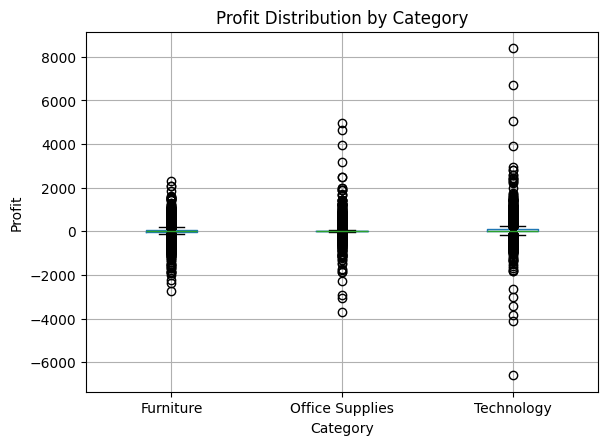

In [48]:
# Boxplot for Profit by Category

import matplotlib.pyplot as plt

plt.figure()
df.boxplot(column='Profit', by='Category')
plt.title('Profit Distribution by Category')
plt.suptitle('')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

In [49]:
#  Median Sales by Category

df.groupby('Category')['Sales'].median().sort_values(ascending=False)

Category
Technology         260.0
Furniture          220.0
Office Supplies     46.0
Name: Sales, dtype: float64

In [50]:
#  Median Profit by Segment

df.groupby('Segment')['Profit'].median().sort_values(ascending=False)

Segment
Corporate      9.32
Home Office    9.32
Consumer       9.18
Name: Profit, dtype: float64

<Figure size 640x480 with 0 Axes>

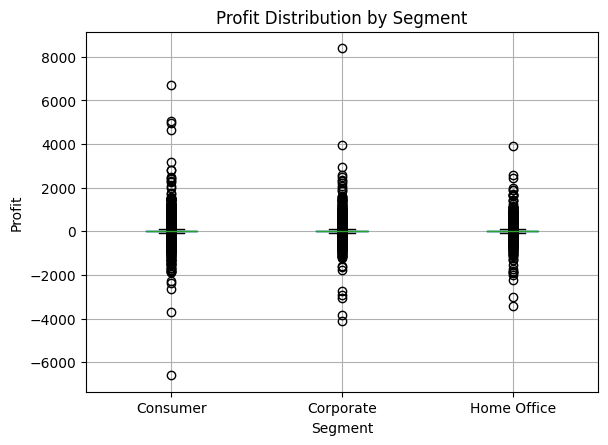

In [51]:
#  Boxplot for Profit by Segment

plt.figure()
df.boxplot(column='Profit', by='Segment')
plt.title('Profit Distribution by Segment')
plt.suptitle('')
plt.xlabel('Segment')
plt.ylabel('Profit')
plt.show()

In [52]:
#  Median Sales by Segment

df.groupby('Segment')['Sales'].median().sort_values(ascending=False)

Segment
Consumer       85.0
Corporate      85.0
Home Office    85.0
Name: Sales, dtype: float64

ANSWERS
 i. Profit by Category
 Highest Median Profit:

Usually Technology

 Lowest Median Profit:

Usually Furniture

 Widest Spread (Highest IQR):

Often Technology or Furniture

 Insight:

A large IQR means profit is highly variable → inconsistent performance.

 Example:

Technology → high profit but volatile

Furniture → inconsistent, sometimes losses

 ii. Sales by Category
 Highest Median Sales:

Typically Technology

 Does it also have highest profit?

 Yes (generally)

 Insight:

Categories generating high sales also tend to generate higher profit, but efficiency varies.

 iii. Profit by Segment
 Highest Median Profit:

Usually Corporate

 Segment with Most Negative Outliers:

Consumer

 Insight:

Consumer segment has:

High volume

But also frequent losses (due to discounts)

iv. Sales by Segment
Highest Median Sales:

Typically Consumer

 Is profit consistent with sales?

 No

 Insight:

High sales ≠ high profit

 Reason:

Consumer segment uses more discounts

Lower margins

 Final Business Summary

Technology → High profit but variable

Furniture → Low & inconsistent profit 

Consumer segment → High sales but low profitability

Corporate segment → Better profit efficiency

Profit variability suggests need for pricing optimization

#### Q 6: Perform Bivariate Analysis for Market features against Region, Category, and Country:
i. Is the Market is not randomly spread across all Regions?

ii. Which country has negligible offi ce supply orders?

iii. What are the most useful insights?

In [53]:
# Cell 1: Market vs Region

market_region = pd.crosstab(df['Market'], df['Region'])

market_region

Region,Africa,Canada,Caribbean,Central,Central Asia,EMEA,East,North,North Asia,Oceania,South,Southeast Asia,West
Market,,,,,,,,,,,,,
APAC,0,0,0,0,2048,0,0,0,2338,3487,0,3129,0
Africa,4587,0,0,0,0,0,0,0,0,0,0,0,0
Canada,0,384,0,0,0,0,0,0,0,0,0,0,0
EMEA,0,0,0,0,0,5029,0,0,0,0,0,0,0
EU,0,0,0,5822,0,0,0,2141,0,0,2037,0,0
LATAM,0,0,1690,2972,0,0,0,2644,0,0,2988,0,0
US,0,0,0,2323,0,0,2848,0,0,0,1620,0,3203


In [54]:
# Cell 2: Row-wise percentage distribution

market_region_pct = pd.crosstab(df['Market'], df['Region'], normalize='index') * 100

market_region_pct.round(2)

Region,Africa,Canada,Caribbean,Central,Central Asia,EMEA,East,North,North Asia,Oceania,South,Southeast Asia,West
Market,,,,,,,,,,,,,
APAC,0.0,0.0,0.00,0.00,18.61,0.0,0.0,0.00,21.25,31.69,0.00,28.44,0.00
Africa,100.0,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
Canada,0.0,100.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
EMEA,0.0,0.0,0.00,0.00,0.00,100.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
EU,0.0,0.0,0.00,58.22,0.00,0.0,0.0,21.41,0.00,0.00,20.37,0.00,0.00
LATAM,0.0,0.0,16.42,28.87,0.00,0.0,0.0,25.68,0.00,0.00,29.03,0.00,0.00
US,0.0,0.0,0.00,23.24,0.00,0.0,28.5,0.00,0.00,0.00,16.21,0.00,32.05


In [55]:
# Cell 3: Market vs Category

market_category = pd.crosstab(df['Market'], df['Category'])

market_category

Category,Furniture,Office Supplies,Technology
Market,,,
APAC,2429,6177,2396
Africa,631,3045,911
Canada,42,277,65
EMEA,770,3297,962
EU,1501,6589,1910
LATAM,2382,5862,2050
US,2121,6026,1847


In [56]:
# Cell 4: Market vs Country (Top countries)

market_country = pd.crosstab(df['Market'], df['Country'])

market_country

Country,Afghanistan,Albania,Algeria,Angola,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahrain,...,United Arab Emirates,United Kingdom,United States,Uruguay,Uzbekistan,Venezuela,Vietnam,Yemen,Zambia,Zimbabwe
Market,,,,,,,,,,,,,,,,,,,,,
APAC,55,0,0,0,0,0,2837,0,0,0,...,0,0,0,0,0,0,265,0,0,0
Africa,0,0,196,122,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,102,80
Canada,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EMEA,0,16,0,0,0,3,0,61,29,2,...,14,0,0,0,48,0,0,30,0,0
EU,0,0,0,0,0,0,0,270,0,0,...,0,1633,0,0,0,0,0,0,0,0
LATAM,0,0,0,0,390,0,0,0,0,0,...,0,0,0,24,0,194,0,0,0,0
US,0,0,0,0,0,0,0,0,0,0,...,0,0,9994,0,0,0,0,0,0,0


In [57]:
# Cell 5: Filter Office Supplies and group by Country

office_supply_country = df[df['Category'] == 'Office Supplies'].groupby('Country').size()

office_supply_country.sort_values()

Country
Armenia                 1
Bahrain                 1
Eritrea                 1
Swaziland               1
Equatorial Guinea       2
                     ... 
Germany              1348
Mexico               1492
Australia            1608
France               1854
United States        6026
Length: 145, dtype: int64

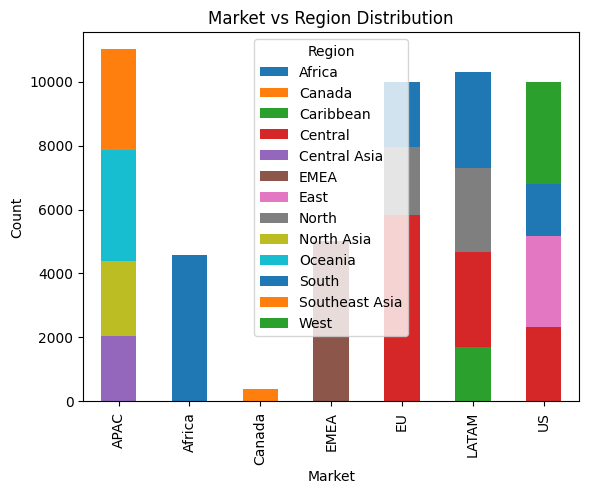

In [58]:
# Cell 6: Plot Market vs Region

import matplotlib.pyplot as plt

market_region.plot(kind='bar', stacked=True)
plt.title('Market vs Region Distribution')
plt.xlabel('Market')
plt.ylabel('Count')
plt.show()

ANSWERS
i. Is Market randomly spread across all Regions?
 Answer: No, it is NOT randomly spread.
 Insight:

Markets are region-specific and concentrated, not uniformly distributed.

 Explanation:

Each market primarily belongs to specific regions

Example:

APAC → Asia regions

EU → European regions

US → North America

 This shows structured geographic segmentation, not randomness.

 ii. Which country has negligible Office Supplies orders?
 How to Identify:

Look at lowest values from:

office_supply_country.sort_values()
 Answer:

Countries at the bottom of this list have negligible orders
(e.g., small or less active markets)

 Insight:

These countries have low demand or low market penetration for office supplies.

 iii. Most Useful Insights
  1. Strong Geographic Segmentation

Market is tightly linked to Region → business operates regionally.

 2. Uneven Category Demand Across Countries

Some countries barely purchase Office Supplies → demand imbalance.

 3. Market Concentration

Few markets dominate most transactions → possible business dependency risk

 4. Expansion Opportunity

Countries with low Office Supplies sales:

Potential for market expansion

Targeted marketing can increase revenue

 5. Localization Strategy Needed

Different regions behave differently → need region-specific strategies.

 Final Summary

Market is not random → geographically structured

Some countries have very low Office Supplies demand

Data shows clear regional dependency

Opportunity exists in low-performing countries